# Train-Test Split
```In this exercise you will experience with an important and often neglected issue in the data scientist work - the train-test split. For a specific dataset we will examine different ways to split it and will understand the limitations and constraints we have to take when creating a good train-test split.```

```~ Ittai Haran```

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
%matplotlib inline


def maps(func, lister): # if you hate python 3 as much as I do you might want to use this
    return list(map(func, lister))

```First, load the dataset. Notice that the dataset is made out of pairs of objects, where each row has the id of each object and the features related to it. How many different objects are there?
We would like to describe the objects and the data using a specific data structure. What structure can best describe the objects and the relations between them (what two objects happen to be in the same sample)?```

In [3]:
df = pd.read_csv('data.csv', index_col=0)
df.head()

,index_left,index_right,feature_1_left,feature_2_left,feature_3_left,feature_4_left,feature_5_left,feature_6_left,feature_7_left,feature_8_left,...,feature_92_right,feature_93_right,feature_94_right,feature_95_right,feature_96_right,feature_97_right,feature_98_right,feature_99_right,feature_100_right,target
0,926_1,407_2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,10.8
1,798_1,431_2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,11.8
2,5761_1,2602_2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.6
3,6847_1,3227_2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4.4
4,9163_1,4377_2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.0


```Use networkx to create a graph describing the objects and the relations between them. How many connected components the graph has? Draw a histogram of their sizes. Are there any edges between left objects and right objects? That kind of graph is called a bipartite graph. For any graph computations, networkx is your friend, and it should be very easy.```

(array([151.,  45.,   5.,   7.,   1.,   1.,   0.,   0.,   2.,   1.]),
 array([  2. ,  86.4, 170.8, 255.2, 339.6, 424. , 508.4, 592.8, 677.2,
        761.6, 846. ]),
 <BarContainer object of 10 artists>)

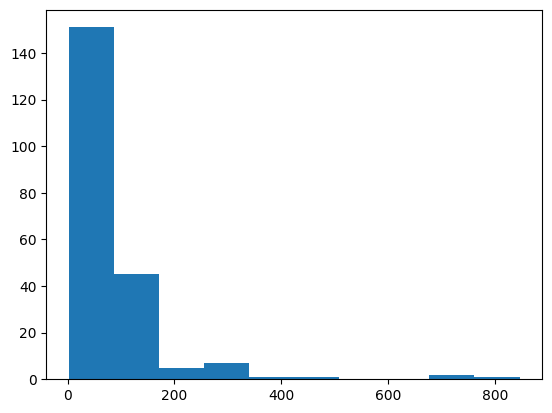

In [4]:
graph = nx.from_pandas_edgelist(df, source="index_left", target="index_right", edge_attr="target")
concomp = [c for c in nx.connected_components(graph)]
plt.hist([len(c) for c in concomp])

```In order to get a baseline model we will try to have predictions using only one object from each sample. Create a dataset containing only the left objects. Drop duplicates, so every object will appear only once.```

In [5]:
df_left = df.drop(columns=["index_right"] + [f"feature_{i}_right" for i in range(1, 101)]).drop_duplicates()

```Split your data randomly with ratio 0.7-0.3. Train a simple model (a random forest, maybe?) to predict the target. Make sure your model isn't overfitted, and try to get the best score you can (on the test segment). Compare your results to a simple baseline - the mean of the target computed on the train segment.```

In [6]:
inputs = df_left.drop(columns=["target", "index_left"])
target = df_left["target"]
def train_test_baseline(inputs, target):
    x_train, x_test, y_train, y_test = train_test_split(inputs, target, test_size=0.3)
    clf = RandomForestRegressor(max_depth=16).fit(x_train, y_train)
    baseline_mse = mean_squared_error(y_test, np.mean(y_train) + np.zeros(y_test.shape))
    test_mse = mean_squared_error(y_test, clf.predict(x_test))
    train_mse = mean_squared_error(y_train, clf.predict(x_train))
    print(f"Baseline MSE: {baseline_mse}\n Test MSE: {test_mse}\n Train MSE: {train_mse}")
train_test_baseline(inputs, target)


Baseline MSE: 9.609131818732045
 Test MSE: 1.590185824957272
 Train MSE: 1.1587140288811875


```Repeat that process, only this use all of the sample, and not just the left object. Accordingly, you don't have to drop any duplicates. Use the naive train-test split. Did you get a good score on both train and test? why (or why not)? Do you think the score you got on the test corresponds to the "real" generalization error? why, or why not?```

In [7]:
inputs = df.drop(columns=["target", "index_left", "index_right"])
target = df["target"]
train_test_baseline(inputs, target)


Baseline MSE: 9.068366129402056
 Test MSE: 0.7710784144258339
 Train MSE: 0.4812490588801106


answer: test score can be great because the test set isnt really seperate from the train set - both contain the same nodes and so the samples (=edges) are far from independent. In particular the test error doesnt correspond well to the actual generalization error, which would entail taking nodes that were truly never seen befroe, i.e. nodes with no edges in the training set

```We will now create a new train-test split, so that every connected component is contained either in the train segment or in the test segment. To do so, implement the following algorithm:```

```while length(train_segment)<0.7*length(data):
    choose randomly a sample s from the data (that is not in train_segment)
    add the connected component containing s to the train_segment
test_segment = data - train_segment```

In [7]:
train_segment = pd.DataFrame()
test_segment = df.copy()
while len(train_segment) < 0.7 * len(df):
    s = test_segment.sample()
    for c in concomp:
        if s["index_left"].iloc[0] in c:
            connected = df.loc[(df["index_left"].isin(c)) & (df["index_right"].isin(c))]
            train_segment = pd.concat((train_segment, connected))
    both = pd.merge(df, train_segment[["index_left", "index_right"]], how="outer", on=["index_left", "index_right"], indicator=True)
    test_segment = both[both["_merge"] == "left_only"].drop(columns="_merge")
test_segment.head()    

C:\Users\yovel\AppData\Local\Temp\ipykernel_15576\3361530331.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  both = pd.merge(df, train_segment[["index_left", "index_right"]], how="outer", on=["index_left", "index_right"], indicator=True)
C:\Users\yovel\AppData\Local\Temp\ipykernel_15576\3361530331.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  both = pd.merge(df, train_segment[["index_left", "index_right"]], how="outer", on=["index_left", "index_right"], indicator=True)
C:\Users\yovel\AppData\Local\Temp\ipykernel_15576\

,index_left,index_right,feature_1_left,feature_2_left,feature_3_left,feature_4_left,feature_5_left,feature_6_left,feature_7_left,feature_8_left,...,feature_92_right,feature_93_right,feature_94_right,feature_95_right,feature_96_right,feature_97_right,feature_98_right,feature_99_right,feature_100_right,target
51,10000_1,4850_2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5.8
52,10000_1,4852_2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4.2
53,10000_1,4855_2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.8
54,10000_1,4857_2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5.4
55,10000_1,4858_2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4.2


```Train a good model using your train segment. What is the best score you can get on your test? What is the problem with the train-test split method we used? Hint: How many connected components are there in the train segment, and how many are in the test segment? Examine also the distribution of the target, both in the train and in the test. Do they look the same?```

Test MSE: 3.8579613991212183
 Train MSE: 0.0853903771422416


'There is large variance in the sizes of the components, we might end up with very few components in the "70%" training set so the learning wont be effective. '

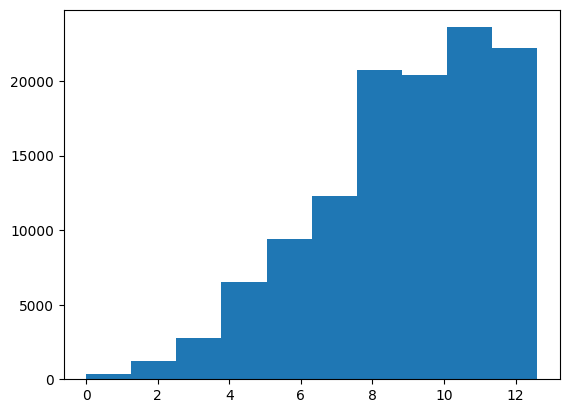

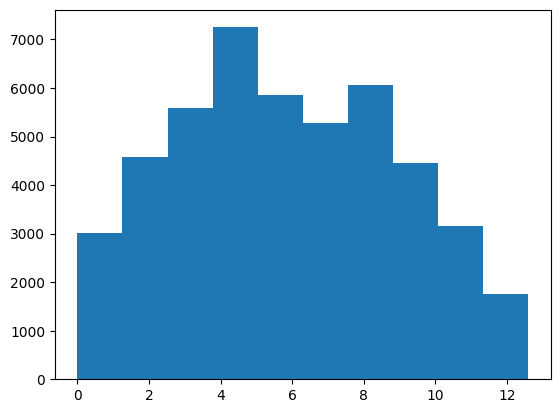

In [12]:
def xy_from_train_test(train_segment, test_segment):
    x_train = train_segment.drop(columns=["index_left", "index_right", "target"])
    x_test = test_segment.drop(columns=["index_left", "index_right", "target"])
    y_train = train_segment["target"]
    y_test = test_segment["target"]
    return x_train, x_test, y_train, y_test


def fit_eval(clf, x_train, x_test, y_train, y_test):
    clf.fit(x_train, y_train)
    test_mse = mean_squared_error(y_test, clf.predict(x_test))
    train_mse = mean_squared_error(y_train, clf.predict(x_train))
    print(f"Test MSE: {test_mse}\n Train MSE: {train_mse}")

clf = RandomForestRegressor(max_depth=18)
x_train, x_test, y_train, y_test = xy_from_train_test(train_segment, test_segment)
plt.figure()
plt.hist(y_train)
plt.figure()
plt.hist(y_test)
fit_eval(clf, x_train, x_test, y_train, y_test)

'''There is large variance in the sizes of the components, we might end up with very few components in the "70%" training set so the learning wont be effective. '''






```Do the train-test split again, only this time make sure you have ~0.7 of the connected components in your train segment, using a different algorithm.```

In [ ]:


def build_df_from_ccs(concomps):
    segment = pd.DataFrame()
    for c in concomps:
        connected = df.loc[(df["index_left"].isin(c)) & (df["index_right"].isin(c))]
        segment = pd.concat((segment, connected))
    return segment


rand_gen = np.random.default_rng(9)


training_indices = rand_gen.choice(np.arange(len(concomp)), size=int(0.7*len(concomp)), replace=False)
test_indices = np.array([i for i in np.arange(len(concomp)) if i not in training_indices])


training_concomp = [concomp[i] for i in training_indices]
testing_concomp = [concomp[i] for i in test_indices]

train_segment = build_df_from_ccs(training_concomp)
test_segment = build_df_from_ccs(testing_concomp)

x_train, x_test, y_train, y_test = xy_from_train_test(train_segment, test_segment)
clf = RandomForestRegressor(max_depth=18)
fit_eval(clf, x_train, x_test, y_train, y_test)





Test MSE: 2.626863465492261
 Train MSE: 0.18475272628283412


```What part of the connected components you have in your train segment this time? Try also look again at the distribution of the target in the two segments.```

0.6995305164319249


(array([ 1105.,  2008.,  2559.,  3917.,  4434.,  5383.,  8550.,  8581.,
        10507., 10784.]),
 array([ 0.  ,  1.26,  2.52,  3.78,  5.04,  6.3 ,  7.56,  8.82, 10.08,
        11.34, 12.6 ]),
 <BarContainer object of 10 artists>)

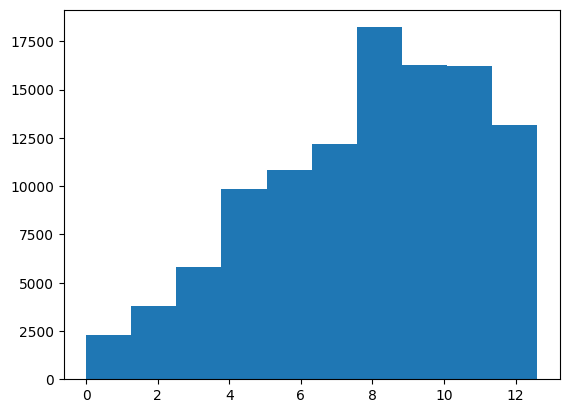

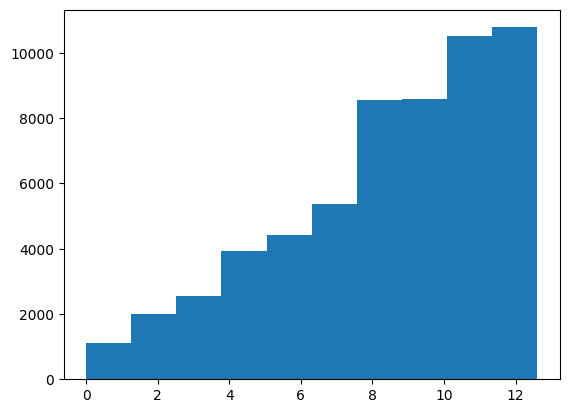

In [11]:
print(int(0.7*len(concomp))/len(concomp))
plt.figure()
plt.hist(y_train)
plt.figure()
plt.hist(y_test)

```Train a good model using you train segment. What is the best score you can get on your test? Did you get a better score? why?```

In [ ]:
'''score is better since we train on more components'''

Bonus: the data for this exercise was uniquely generated, using MNIST (what? how???). Generating toy datasets is a very useful tool for a data scientist - it can help test hypotheses in small scale or extreme cases. 

How would you approach the problem of creating the dataset for this exercise (either on MNIST or based on another dataset)? Think of the following questions, write the answers and be prepared to discuss them with your instructor:
1. What "features" will the dataset be made of? Remember we want a dataset which uses pairs of objects
2. How will the label be defined?
3. How would you choose which pairs to sample for the dataset? Think for instance if you wanted to create the case, decribed in the exercise, where some of the connected components are very big - how would you do this? What parameters impact this?